## Real ChatBoat:
- coantain chating: you can chat with the bot in real-time.
- Conatain RAG: you can ask the bot to retrieve information from a knowledge base.
- Contain Tools: the bot can use various tools to assist you with tasks.
- Contain UI: the bot has a user-friendly interface for easy interaction.
- Contain Langsmith etc

### Also use the memory concempt and prsistance, human in the loop etc

In [41]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv 
from langgraph.checkpoint.memory import MemorySaver
from langchain_openrouter import ChatOpenRouter

In [42]:
load_dotenv()

True

In [43]:
from langgraph.graph.message import add_messages
class ChatState(TypedDict):

    messages: Annotated[list[BaseMessage], add_messages]

In [54]:
llm = ChatOpenRouter(
    model= 'google/gemma-4-26b-a4b-it:free'
)

In [45]:

def chat_node(state:ChatState):

    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [46]:
check_pointer = MemorySaver()

graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)

graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatboat = graph.compile(checkpointer=check_pointer)


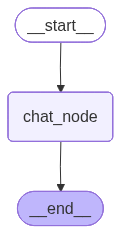

In [47]:
chatboat

In [48]:
initial_state = {
    'message': [HumanMessage(content='What is the capital of india')]
}

# chatboat.invoke(initial_state)

In [55]:
thread_id = '1'

while True:
    user_message = input("Type here: ")

    print('User:', user_message)
    if user_message.strip().lower() in ['exit','bye','quit']:
        break
    
    config = {'configurable':{'thread_id': thread_id}}
    response = chatboat.invoke({'messages':[HumanMessage(content = user_message)]}, config=config)

    print('AI:', response['messages'][-1].content)


User: my name is saeed


UnauthorizedResponseError: User not found.

In [ ]:
chatboat.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='My name is saeed', additional_kwargs={}, response_metadata={}, id='4e72bc36-5a0e-45f7-b1f7-42d4e22d1554')]}, next=('chat_node',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f175ff8-716a-6aa7-8000-a54f01a4a2c4'}}, metadata={'source': 'loop', 'step': 0, 'parents': {}}, created_at='2026-07-02T10:19:36.871565+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f175ff8-7102-615f-bfff-fbdad056365d'}}, tasks=(PregelTask(id='2633f390-7c04-8f04-f6a9-c23a63536e8a', name='chat_node', path=('__pregel_pull', 'chat_node'), error=None, interrupts=(), state=None, result=None),), interrupts=())